<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2Fefficientnetb0/notebooks/04_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EfficientNetB0 - Brain Tumor MRI Classification

This notebook implements an EfficientNetB0 model for supervised classification of brain MRI images into four classes:

- 0 - Glioma
- 1 - Meningioma
- 2 - No Tumor
- 3 - Pituitary

The experiment follows the common dataset splits and training settings defined for the group project.

## 1. Environment and Configuration

In [ ]:
# Check the environment and set reproducibility

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from PIL import Image
from IPython.display import display

SEED = 42

tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Seed:", SEED)

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed: 42


In [ ]:
# Connect to Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Set dataset paths

DATASET_PATH = "/content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset"
SPLIT_PATH = os.path.join(DATASET_PATH, "splits")

print("Dataset path:", DATASET_PATH)
print("Split path:", SPLIT_PATH)

Dataset path: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset
Split path: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/splits


In [ ]:
# Set common training settings

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
NUM_CLASSES = 4
LEARNING_RATE = 0.001

CLASS_NAMES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Seed:", SEED)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Batch size: 16
Epochs: 10
Learning rate: 0.001
Seed: 42
Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


## 2. Dataset and Data Splits

In [ ]:
# Load and verify the common train, validation, and test splits

train_df = pd.read_csv(os.path.join(SPLIT_PATH, "train.csv"))
val_df = pd.read_csv(os.path.join(SPLIT_PATH, "val.csv"))
test_df = pd.read_csv(os.path.join(SPLIT_PATH, "test.csv"))

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nColumns:", train_df.columns.tolist())

print("\nTraining class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Train: (4480, 3)
Validation: (1120, 3)
Test: (1600, 3)

Columns: ['filepath', 'label', 'class_name']

Training class distribution:
label
0    1120
1    1120
2    1120
3    1120
Name: count, dtype: int64

Validation class distribution:
label
0    280
1    280
2    280
3    280
Name: count, dtype: int64

Test class distribution:
label
0    400
1    400
2    400
3    400
Name: count, dtype: int64


Relative path: Training/pituitary/Tr-pi_135.jpg
Full path: /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Training/pituitary/Tr-pi_135.jpg
File exists: True
Image size: (512, 512)
Image mode: RGB


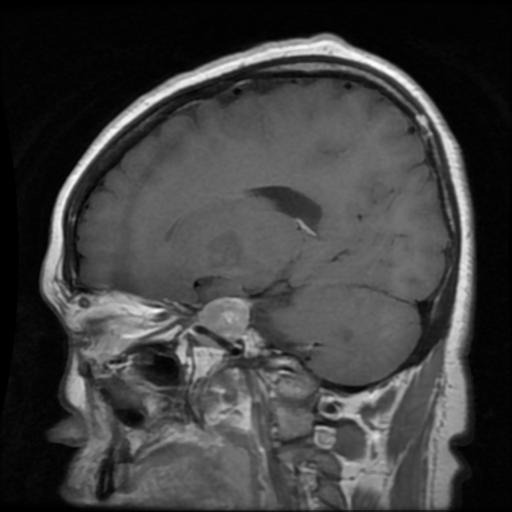

In [ ]:
# Verify that the CSV paths point to real MRI images

sample_relative_path = train_df.iloc[0]["filepath"]
sample_full_path = os.path.join(DATASET_PATH, sample_relative_path)

print("Relative path:", sample_relative_path)
print("Full path:", sample_full_path)
print("File exists:", os.path.exists(sample_full_path))

img = Image.open(sample_full_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

display(img)

## 3. Image Preprocessing

In [ ]:
# Define image loading and training augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
], name="data_augmentation")


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [ ]:
# Create TensorFlow datasets from the CSV splits

def create_dataset(df, shuffle=False, augment=False):
    paths = [
        os.path.join(DATASET_PATH, path)
        for path in df["filepath"].astype(str)
    ]

    labels = df["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment:
        ds = ds.map(
            lambda image, label: (data_augmentation(image, training=True), label),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = create_dataset(train_df, shuffle=True, augment=True)
val_ds = create_dataset(val_df, shuffle=False, augment=False)
test_ds = create_dataset(test_df, shuffle=False, augment=False)

print("Datasets created successfully.")

Datasets created successfully.


In [ ]:
# Check the shape of one batch

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


## 4. EfficientNetB0 Model

EfficientNetB0 is used as a pretrained feature extractor with ImageNet weights. The pretrained backbone is kept frozen during the initial training phase, and a new classification head is added for the four brain tumor classes.

In [ ]:
# Load the pretrained EfficientNetB0 backbone

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

print("Base model:", base_model.name)
print("Trainable:", base_model.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model: efficientnetb0
Trainable: False


In [ ]:
# Build the EfficientNetB0 classification model

inputs = keras.Input(shape=(*IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compile the model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Verify the model configuration

print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Trainable parameters:", model.count_params() - base_model.count_params())
print("Total parameters:", model.count_params())

Input shape: (None, 224, 224, 3)
Output shape: (None, 4)
Trainable parameters: 5124
Total parameters: 4054695


## 5. Model Training

The EfficientNetB0 model is trained using the shared training and validation splits. The pretrained ImageNet backbone remains frozen during this baseline experiment.

The training configuration uses:
- Batch size: 16
- Maximum epochs: 10
- Random seed: 42
- Optimizer: Adam
- Learning rate: 0.001
- Loss: Sparse categorical cross-entropy
- Data augmentation: horizontal flip, small rotation, and small zoom
- Early stopping based on validation loss
- Model checkpointing based on validation accuracy

In [ ]:
# Train the EfficientNetB0 model with early stopping and checkpointing

checkpoint_path = "/content/efficientnetb0_best.keras"

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time / 60:.2f} minutes")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 820s 3s/step - accuracy: 0.7487 - loss: 0.6611 - val_accuracy: 0.8080 - val_loss: 0.4995
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 62s 222ms/step - accuracy: 0.8297 - loss: 0.4561 - val_accuracy: 0.7946 - val_loss: 0.5269
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 60s 215ms/step - accuracy: 0.8598 - loss: 0.3953 - val_accuracy: 0.8250 - val_loss: 0.4526
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 60s 214ms/step - accuracy: 0.8578 - loss: 0.3796 - val_accuracy: 0.8196 - val_loss: 0.4687
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 215ms/step - accuracy: 0.8665 - loss: 0.3576 - val_accuracy: 0.8339 - val_loss: 0.4471
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 61s 217ms/step - accuracy: 0.8775 - loss: 0.3355 - val_accuracy: 0.8464 - val_loss: 0.4073
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 61s 216ms/step - accuracy: 0.8797 - loss: 0.3222 - val_accuracy: 0.8741 - val_loss: 0.3295
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 62s 223ms/step - accuracy: 0.8821 - loss: 0.3

## 6. Training Results

In [15]:
# Display the training history

history_df = pd.DataFrame(history.history)

print(history_df)

   accuracy      loss  val_accuracy  val_loss
0  0.748661  0.661089      0.808036  0.499456
1  0.829687  0.456140      0.794643  0.526940
2  0.859821  0.395330      0.825000  0.452556
3  0.857813  0.379621      0.819643  0.468746
4  0.866518  0.357625      0.833929  0.447083
5  0.877455  0.335519      0.846429  0.407337
6  0.879687  0.322201      0.874107  0.329520
7  0.882143  0.317664      0.836607  0.430954
8  0.887500  0.303617      0.852679  0.395589
9  0.890402  0.300959      0.842857  0.433741


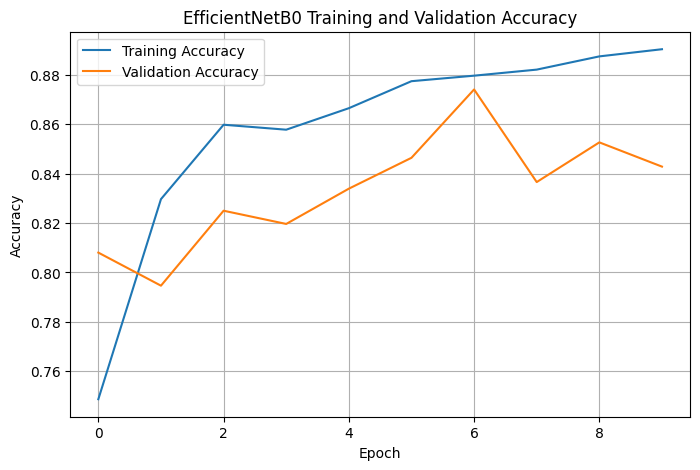

In [16]:
# Plot training and validation accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

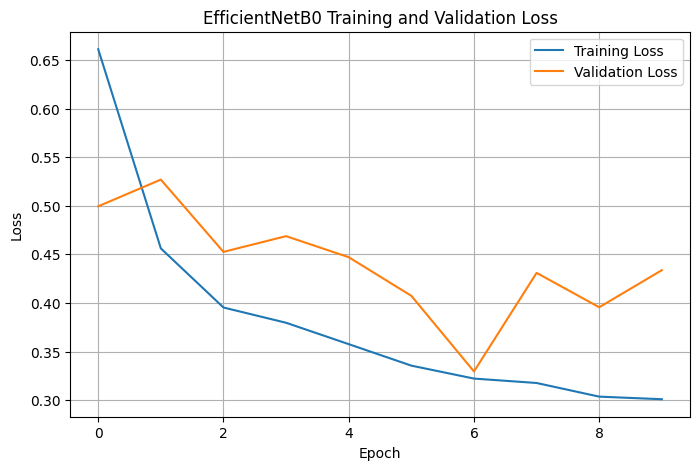

In [17]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 7. Test Evaluation
The final test set is evaluated only after training. The test set was kept separate from the training and validation data throughout the experiment.

In [18]:
# Evaluate the model on the unseen test set

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.8388 - loss: 0.4669

Test loss: 0.4669
Test accuracy: 0.8388
Test accuracy: 83.88%


In [19]:
# Generate predictions on the test set

y_true = []
y_prob = []

for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0)
    y_prob.extend(probabilities)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("Number of test samples:", len(y_true))
print("Prediction shape:", y_prob.shape)

Number of test samples: 1600
Prediction shape: (1600, 4)


In [20]:
# Calculate precision, recall, and F1-score

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      Glioma     0.8916    0.6375    0.7434       400
  Meningioma     0.7563    0.7525    0.7544       400
    No Tumor     0.8947    0.9775    0.9343       400
   Pituitary     0.8246    0.9875    0.8987       400

    accuracy                         0.8387      1600
   macro avg     0.8418    0.8387    0.8327      1600
weighted avg     0.8418    0.8387    0.8327      1600



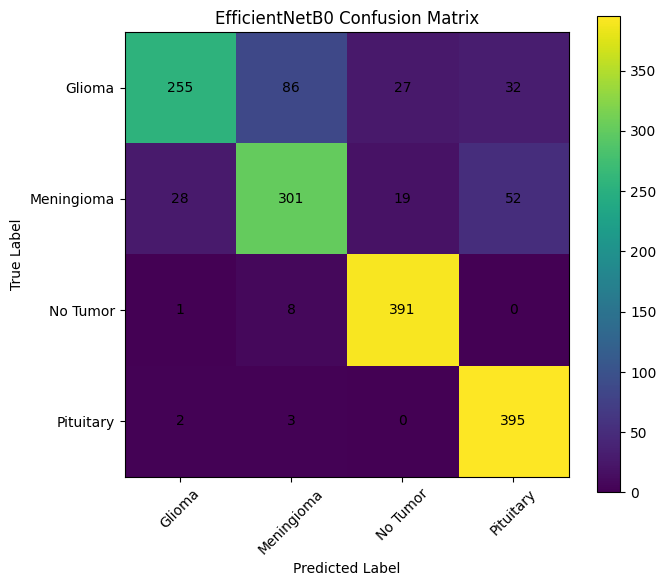

In [21]:
# Plot the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 8. Class-Specific Analysis

In [22]:
# Calculate per-class precision, recall, and F1-score

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    zero_division=0
)

class_metrics = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print(class_metrics.to_string(index=False))

     Class  Precision  Recall  F1-Score  Support
    Glioma   0.891608  0.6375  0.743440      400
Meningioma   0.756281  0.7525  0.754386      400
  No Tumor   0.894737  0.9775  0.934289      400
 Pituitary   0.824635  0.9875  0.898749      400


In [23]:
# Identify the main class-to-class prediction errors

error_mask = y_true != y_pred

error_pairs = pd.DataFrame({
    "True Class": y_true[error_mask],
    "Predicted Class": y_pred[error_mask]
})

error_counts = (
    error_pairs
    .value_counts()
    .reset_index(name="Count")
)

error_counts["True Class"] = error_counts["True Class"].map(
    dict(enumerate(CLASS_NAMES))
)

error_counts["Predicted Class"] = error_counts["Predicted Class"].map(
    dict(enumerate(CLASS_NAMES))
)

print(error_counts.to_string(index=False))

True Class Predicted Class  Count
    Glioma      Meningioma     86
Meningioma       Pituitary     52
    Glioma       Pituitary     32
Meningioma          Glioma     28
    Glioma        No Tumor     27
Meningioma        No Tumor     19
  No Tumor      Meningioma      8
 Pituitary      Meningioma      3
 Pituitary          Glioma      2
  No Tumor          Glioma      1


In [24]:
# Display the main evaluation metrics

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

print(f"Test accuracy:   {test_accuracy:.4f}")
print(f"Macro precision: {report_dict['macro avg']['precision']:.4f}")
print(f"Macro recall:    {report_dict['macro avg']['recall']:.4f}")
print(f"Macro F1-score:  {report_dict['macro avg']['f1-score']:.4f}")

Test accuracy:   0.8388
Macro precision: 0.8418
Macro recall:    0.8387
Macro F1-score:  0.8327
